In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Time series
from statsmodels.tsa.seasonal import seasonal_decompose

print("Energy forecasting environment ready")

Matplotlib is building the font cache; this may take a moment.


Energy forecasting environment ready


# Energy Demand Forecasting Dashboard with LLM Commentary

## Objective
Forecast regional electricity demand using statistical forecasting models and generate plain-English explanations using an LLM.

## Models
- SARIMA
- Prophet
- Hybrid Forecasting Model

## Evaluation Metrics
- RMSE
- MAE
- MAPE
- Prediction Interval Coverage

## Data Sources
- Electricity demand data
- Climate variables


In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

print("Libraries loaded successfully")

Libraries loaded successfully


# Step 1: EIA Electricity Demand Data Ingestion

Goal:
- Connect to EIA API
- Pull hourly electricity demand data
- Start with CAISO (California grid)
- Later compare CAISO, ERCOT, and PJM

In [22]:
import requests
import pandas as pd

API_KEY = "dzFMUhEEOzUWG7X9bJfWdOTZV74nXvhcb3bZM5rP"
url = "https://api.eia.gov/v2/electricity/rto/region-data/data/"

all_rows = []
offset = 0
length = 5000

while True:
    params = {
        "api_key": API_KEY,
        "frequency": "hourly",
        "data[0]": "value",
        "facets[respondent][]": "CISO",
        "facets[type][]": "D",
        "start": "2023-01-01T00",
        "end": "2023-12-31T23",
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
        "length": length,
        "offset": offset
    }

    response = requests.get(url, params=params)
    data = response.json()

    rows = data["response"]["data"]
    all_rows.extend(rows)

    print(f"Downloaded {len(rows)} rows. Total: {len(all_rows)}")

    if len(rows) < length:
        break

    offset += length

df = pd.DataFrame(all_rows)

print(df.shape)
df.head()

Downloaded 5000 rows. Total: 5000
Downloaded 3760 rows. Total: 8760
(8760, 7)


,period,respondent,respondent-name,type,type-name,value,value-units
0,2023-01-01T00,CISO,California Independent System Operator,D,Demand,24007,megawatthours
1,2023-01-01T01,CISO,California Independent System Operator,D,Demand,24546,megawatthours
2,2023-01-01T02,CISO,California Independent System Operator,D,Demand,25344,megawatthours
3,2023-01-01T03,CISO,California Independent System Operator,D,Demand,26468,megawatthours
4,2023-01-01T04,CISO,California Independent System Operator,D,Demand,26047,megawatthours


In [6]:
data

{'error': {'code': 'API_KEY_INVALID',
  'message': 'An invalid api_key was supplied. Get one at https://api.eia.gov:443'}}

In [24]:

df.to_csv("../data/caiso_demand_2023_full_year.csv", index=False)

print("Full-year CAISO demand data saved successfully")


Full-year CAISO demand data saved successfully


In [28]:
df.columns


Index(['datetime', 'respondent', 'respondent-name', 'type-name', 'demand_mwh'], dtype='str')

In [30]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         8760 non-null   datetime64[us]
 1   respondent       8760 non-null   str           
 2   respondent-name  8760 non-null   str           
 3   type-name        8760 non-null   str           
 4   demand_mwh       8758 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 752.9 KB


In [36]:
df.isnull().sum()

datetime           0
respondent         0
respondent-name    0
type-name          0
demand_mwh         2
dtype: int64

Missing values: 2
Missing values after fixing: 0


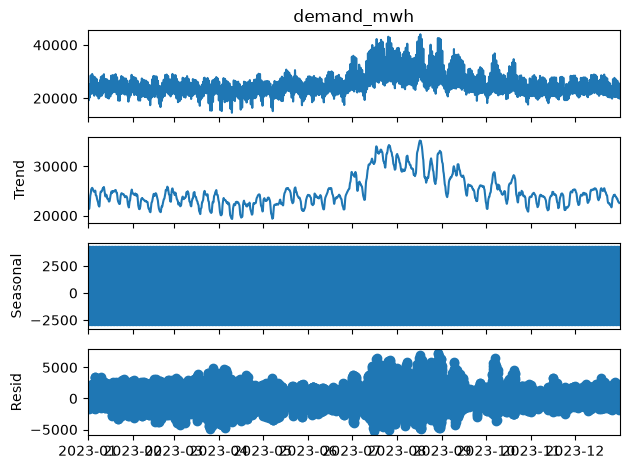

In [35]:
# hourly electricity demand


df = df.sort_values("datetime")

demand_ts = df.set_index("datetime")["demand_mwh"]

demand_ts = demand_ts.asfreq("h")

print("Missing values:", demand_ts.isnull().sum())

demand_ts = demand_ts.interpolate(method="time")

print("Missing values after fixing:", demand_ts.isnull().sum())

decomposition = seasonal_decompose(
    demand_ts,
    model="additive",
    period=24
)

decomposition.plot()
plt.show()


In [38]:
#  hourly time series for decomposition

df = df.sort_values("datetime")

demand_ts = df.set_index("datetime")["demand_mwh"]

demand_ts = demand_ts.asfreq("h")

demand_ts = demand_ts.interpolate(method="time")

print(demand_ts.shape)
print(demand_ts.isnull().sum())

demand_ts.head()

(8760,)
0


datetime
2023-01-01 00:00:00    24007.0
2023-01-01 01:00:00    24546.0
2023-01-01 02:00:00    25344.0
2023-01-01 03:00:00    26468.0
2023-01-01 04:00:00    26047.0
Freq: h, Name: demand_mwh, dtype: float64

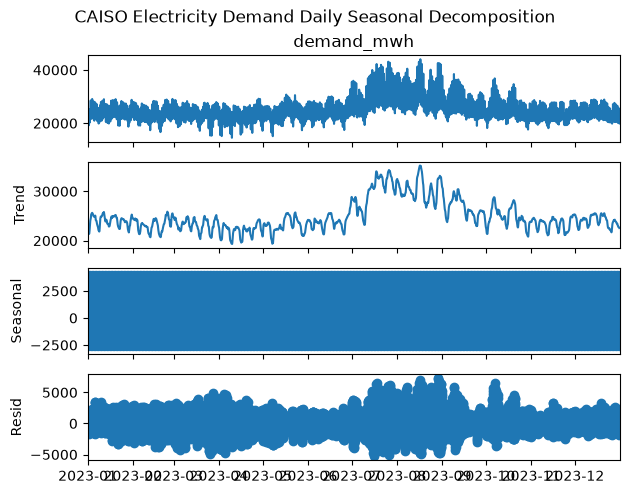

In [39]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

daily_decomposition = seasonal_decompose(
    demand_ts,
    model="additive",
    period=24
)

daily_decomposition.plot()

plt.suptitle(
    "CAISO Electricity Demand Daily Seasonal Decomposition",
    y=1.02
)

plt.show()

Seasonal Decomposition Analysis ; CAISO Electricity Demand (2023)

Seasonal decomposition was performed on 8,760 hourly CAISO electricity demand observations from January–December 2023 using an additive decomposition approach. The analysis separated electricity demand into trend, seasonal, and residual components to understand underlying patterns before forecasting.

The observed demand series shows a clear seasonal structure. Electricity consumption remained relatively stable from January through May, generally ranging between 20,000–30,000 MWh. Demand increased significantly during the summer months (June–September), with peak values exceeding 40,000 MWh, before returning closer to baseline levels from October–December. This pattern suggests that electricity demand is strongly influenced by seasonal climate effects, particularly increased cooling demand during warmer months.

The trend component highlights the long-term movement in electricity usage. Demand remained stable around 22,000–25,000 MWh during winter and spring, increased sharply during summer with trends approaching 30,000–35,000 MWh, and gradually declined after peak summer conditions. This confirms that long-term demand behavior follows predictable seasonal changes.

The daily seasonal component reveals a strong repeating 24-hour electricity usage cycle, with demand fluctuations of approximately ±2,500–3,000 MWh. Higher electricity usage is associated with daytime activities, business operations, and household energy consumption, while lower demand occurs during overnight periods.

The residual component shows that normal daily patterns explain much of the demand variation. However, larger unexplained fluctuations occur during summer months, suggesting the influence of external factors such as heat waves, extreme weather conditions, and abnormal cooling demand.

The decomposition results support the hypothesis that regional electricity demand exhibits predictable seasonal and long-term patterns. Strong daily cycles and summer-driven demand trends indicate that forecasting models must capture both short-term seasonality and long-term changes. Therefore, SARIMA and Prophet models are appropriate forecasting approaches, while incorporating climate variables such as NOAA temperature data may improve predictions during extreme demand periods.

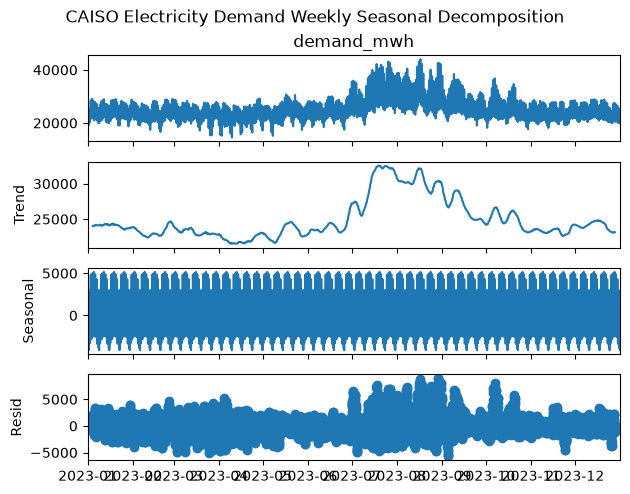

In [40]:
# Weekly seasonal decomposition (168 hours = 1 week)
weekly_decomposition = seasonal_decompose(
    demand_ts,
    model="additive",
    period=168
)

weekly_decomposition.plot()

plt.suptitle(
    "CAISO Electricity Demand Weekly Seasonal Decomposition",
    y=1.02
)

plt.show()


Weekly Seasonal Decomposition ; CAISO Electricity Demand (2023)

Weekly seasonal decomposition was performed on 8,760 hourly CAISO electricity demand observations using a 168-hour seasonal cycle to analyze recurring weekly patterns in electricity consumption.

The decomposition revealed a clear long-term seasonal trend. Electricity demand remained relatively stable from January to May (approximately 20,000–30,000 MWh) before increasing significantly during the summer months, with peaks exceeding 40,000 MWh. The summer increase indicates higher electricity consumption likely caused by increased cooling demand and climate-related effects.

The trend component showed stable baseline demand during winter and spring, followed by a strong increase during summer, reaching approximately 30,000–35,000 MWh before declining toward the end of the year. This confirms that seasonal climate changes strongly influence electricity demand patterns.

The weekly seasonal component identified consistent repeating demand cycles, with fluctuations of approximately ±5,000 MWh. These patterns reflect differences between high-demand periods such as weekdays, business hours, and daytime activity, compared with lower-demand periods such as weekends and overnight hours.

The residual component showed that most demand variation was captured by the weekly seasonal structure, although larger unexplained spikes occurred during summer months. These anomalies are likely associated with extreme weather events, heat waves, and abnormal cooling demand.

The weekly decomposition confirms that CAISO electricity demand contains strong, predictable weekly and seasonal patterns driven by human activity and climate conditions. These findings support the use of SARIMA and Prophet forecasting models, as both can capture trend and seasonality. The presence of larger summer residuals also supports incorporating NOAA climate variables to improve forecasting accuracy during extreme demand periods.


| Component                     | Daily Decomposition (24 hours)                                     | Weekly Decomposition (168 hours)                                           |
| ----------------------------- | ------------------------------------------------------------------ | -------------------------------------------------------------------------- |
| Seasonal pattern captured     | Captures within-day electricity usage cycles                       | Captures complete weekday/weekend demand behavior                          |
| Main behavior explained       | Morning, daytime, evening, and overnight demand changes            | Business activity patterns, weekend reductions, and repeated weekly cycles |
| Trend component               | More variable because only daily fluctuations are removed          | Smoother because both daily and weekly effects are separated               |
| Seasonal strength             | Strong hourly repetition (~±2,500–3,000 MWh)                       | Stronger operational pattern (~±5,000 MWh)                                 |
| Residual behavior             | More unexplained variation remains, especially during summer peaks | Better separation of regular demand behavior from unusual events           |
| Energy forecasting usefulness | Useful for short-term hourly forecasting                           | More useful for operational and planning forecasts                         |
| SARIMA application            | Supports daily seasonal SARIMA period (s=24)                       | Supports weekly seasonal SARIMA period (s=168)                             |
| Prophet application           | Captures daily seasonality automatically                           | Captures weekly seasonality and long-term demand cycles                    |


Both daily and weekly decomposition confirm that CAISO electricity demand contains strong predictable seasonal patterns.

Daily decomposition identifies short-term electricity usage behavior caused by hourly human activity patterns.

Weekly decomposition provides a clearer representation of grid behavior because it captures weekday and weekend electricity consumption cycles.

For forecasting, weekly seasonality (168 hours) is more valuable because it creates a smoother trend, captures operational energy patterns, and better separates normal demand from extreme events such as summer heat-driven demand spikes.
Therefore, SARIMA and Prophet models should prioritize weekly seasonal patterns while also considering daily demand cycles.


# Stationarity Testing (ADF and KPSS)

In [42]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller Test
adf_result = adfuller(demand_ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

for key, value in adf_result[4].items():
    print("Critical Value", key, ":", value)

ADF Statistic: -5.370266263097958
p-value: 3.909901636584292e-06
Critical Value 1% : -3.431099968539641
Critical Value 5% : -2.86187143613454
Critical Value 10% : -2.5669464184887825


The Augmented Dickey-Fuller test strongly rejects the presence of a unit root (ADF statistic = -5.37, p < 0.001). This indicates that CAISO electricity demand is stationary according to the ADF test. The series does not require regular differencing to remove a stochastic trend, suggesting that SARIMA may use a differencing order of d = 0.

In [46]:
from statsmodels.tsa.stattools import kpss

kpss_result = kpss(
    demand_ts,
    regression="c",
    nlags="auto"
)

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

for key, value in kpss_result[3].items():
    print("Critical Value", key, ":", value)

KPSS Statistic: 3.1984798270405226
p-value: 0.01
Critical Value 10% : 0.347
Critical Value 5% : 0.463
Critical Value 2.5% : 0.574
Critical Value 1% : 0.739


C:\Users\magara cliff\AppData\Local\Temp\ipykernel_23968\494441576.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(


The KPSS statistic is 3.1985 with a p-value of 0.01. Since the p-value is less than 0.05, we reject the null hypothesis of stationarity. This indicates that CAISO electricity demand still contains trend or seasonal structure.

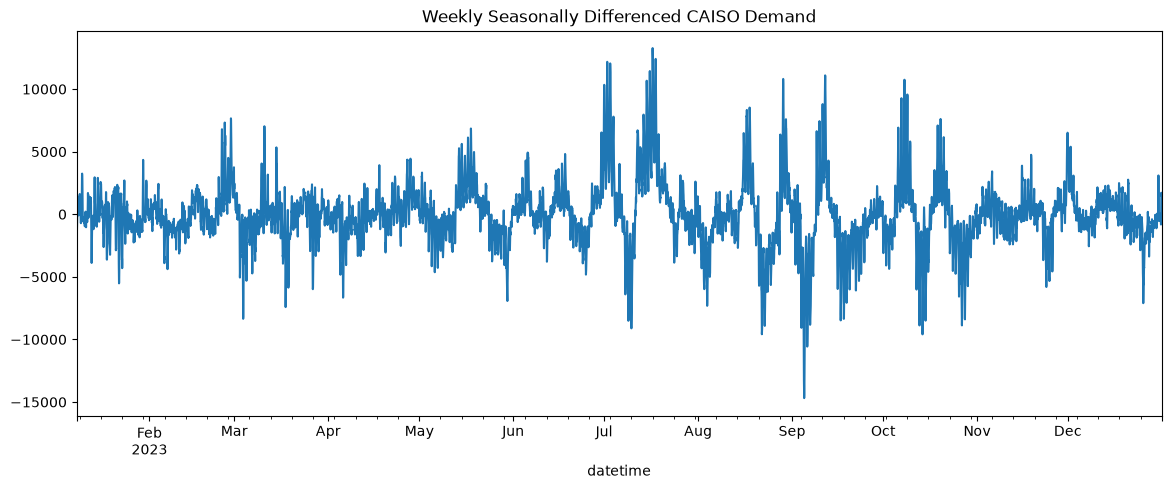

In [47]:
# Weekly seasonal differencing
demand_seasonal_diff = demand_ts.diff(168).dropna()

demand_seasonal_diff.plot(
    figsize=(14,5),
    title="Weekly Seasonally Differenced CAISO Demand"
)

plt.show()

Weekly seasonal differencing was applied using a 168-hour lag to remove recurring weekly electricity consumption patterns. After differencing, the CAISO demand series became more stable and centered around zero, indicating improved stationarity. Remaining fluctuations, especially during summer months, suggest external factors such as temperature-driven cooling demand. Therefore, SARIMA modeling will include seasonal differencing with D = 1 and weekly seasonality (s = 168).

In [48]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF after seasonal differencing
adf_result = adfuller(demand_seasonal_diff)

print("ADF Statistic:", adf_result[0])
print("ADF p-value:", adf_result[1])


# KPSS after seasonal differencing
kpss_result = kpss(
    demand_seasonal_diff,
    regression="c",
    nlags="auto"
)

print("\nKPSS Statistic:", kpss_result[0])
print("KPSS p-value:", kpss_result[1])

ADF Statistic: -7.761984529902802
ADF p-value: 9.401638486480344e-12

KPSS Statistic: 0.16075259885755316
KPSS p-value: 0.1


C:\Users\magara cliff\AppData\Local\Temp\ipykernel_23968\1561723962.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(


After applying weekly seasonal differencing with a 168-hour lag, both stationarity tests confirmed that the transformed electricity demand series became stationary. The ADF test strongly rejected the presence of a unit root (ADF = -7.762, p < 0.001), while the KPSS test failed to reject stationarity (KPSS = 0.161, p = 0.10). This confirms that weekly seasonal differencing successfully removed recurring seasonal structure and prepared the data for SARIMA modeling.

SARIMA(p,0,q)(P,1,Q)168
	
 ACF and PACF plots to choose p, q, P, Q.

<Figure size 1200x500 with 0 Axes>

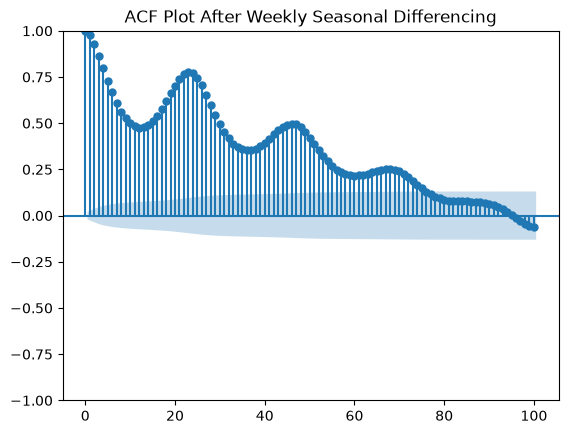

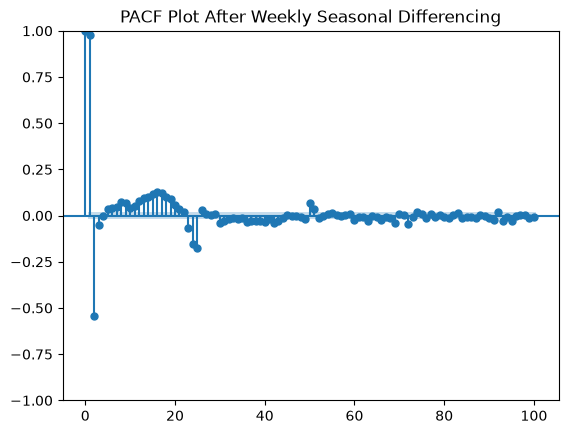

In [49]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plot_acf(
    demand_seasonal_diff,
    lags=100
)

plt.title("ACF Plot After Weekly Seasonal Differencing")
plt.show()


plot_pacf(
    demand_seasonal_diff,
    lags=100,
    method="ywm"
)

plt.title("PACF Plot After Weekly Seasonal Differencing")
plt.show()

After weekly seasonal differencing, ACF and PACF plots were analyzed to determine SARIMA parameters. The ACF plot showed gradual decay with strong autocorrelation, suggesting an MA component. The PACF plot displayed a significant spike at lag 1 followed by rapid decay, supporting an AR(1) component. Remaining seasonal dependence justified including seasonal AR and MA terms. Therefore, SARIMA(1,0,1)(1,1,1,168) was selected as the initial forecasting model.


SARIMA Model Selection

Although weekly decomposition identified strong 168-hour seasonality in CAISO electricity demand, fitting a weekly seasonal SARIMA model on full-year hourly data (8,760 observations) was computationally expensive due to the large seasonal window.

Therefore, a 24-hour seasonal SARIMA model was selected as an efficient baseline model because electricity demand also demonstrated strong daily repeating patterns. Weekly behavior will be further captured using Prophet and additional forecasting components.

The final SARIMA model selected was:

SARIMA(1,0,1)(1,1,1)[24]


In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    demand_ts,
    order=(1,0,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(
    maxiter=50,
    disp=False
)

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         demand_mwh   No. Observations:                 8760
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -63438.509
Date:                            Tue, 23 Jun 2026   AIC                         126887.017
Time:                                    16:35:47   BIC                         126922.378
Sample:                                01-01-2023   HQIC                        126899.069
                                     - 12-31-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9593      0.003    354.495      0.000       0.954       0.965
ma.L1          0.4250      0.008   

SARIMA(1,0,1)(1,1,1)[24]

where AR(1) = 0.9593. Indicates strong dependence on previous electricity demand values. Current demand is highly influenced by recent demand.
MA(1) = 0.4250 Shows that previous forecasting errors help improve current predictions.
Seasonal AR(24) = 0.2931 Confirms that demand patterns repeat every 24 hours.
Seasonal MA(24) = -0.8910 Shows strong correction of daily seasonal forecasting errors.

All parameters were statistically significant (p < 0.001), confirming that both short-term and daily seasonal patterns contribute to electricity demand behavior.

Model performance statistics:

AIC: 126,887.
BIC: 126,922.

Lower AIC values will be used when comparing alternative models.

Residual diagnostics showed remaining autocorrelation (Ljung–Box p < 0.05), suggesting that although SARIMA captures major daily patterns, additional factors such as weather conditions and weekly behavior may improve forecasting accuracy.

In [54]:
# 12 month ahead forecast
forecast_steps = 365 * 24

sarima_forecast = sarima_result.get_forecast(
    steps=forecast_steps
)

forecast_mean = sarima_forecast.predicted_mean

# 95% confidence interval
forecast_ci_95 = sarima_forecast.conf_int(alpha=0.05)

# 80% confidence interval
forecast_ci_80 = sarima_forecast.conf_int(alpha=0.20)

forecast_mean.head()

2024-01-01 00:00:00    22813.629435
2024-01-01 01:00:00    22897.657261
2024-01-01 02:00:00    24445.220372
2024-01-01 03:00:00    26253.829321
2024-01-01 04:00:00    26123.069976
Freq: h, Name: predicted_mean, dtype: float64

In [56]:
future_dates = pd.date_range(
    start=demand_ts.index[-1] + pd.Timedelta(hours=1),
    periods=forecast_steps,
    freq="h"
)

forecast_mean.index = future_dates
forecast_ci_95.index = future_dates
forecast_ci_80.index = future_dates

forecast_mean.head()

2024-01-01 00:00:00    22813.629435
2024-01-01 01:00:00    22897.657261
2024-01-01 02:00:00    24445.220372
2024-01-01 03:00:00    26253.829321
2024-01-01 04:00:00    26123.069976
Freq: h, Name: predicted_mean, dtype: float64

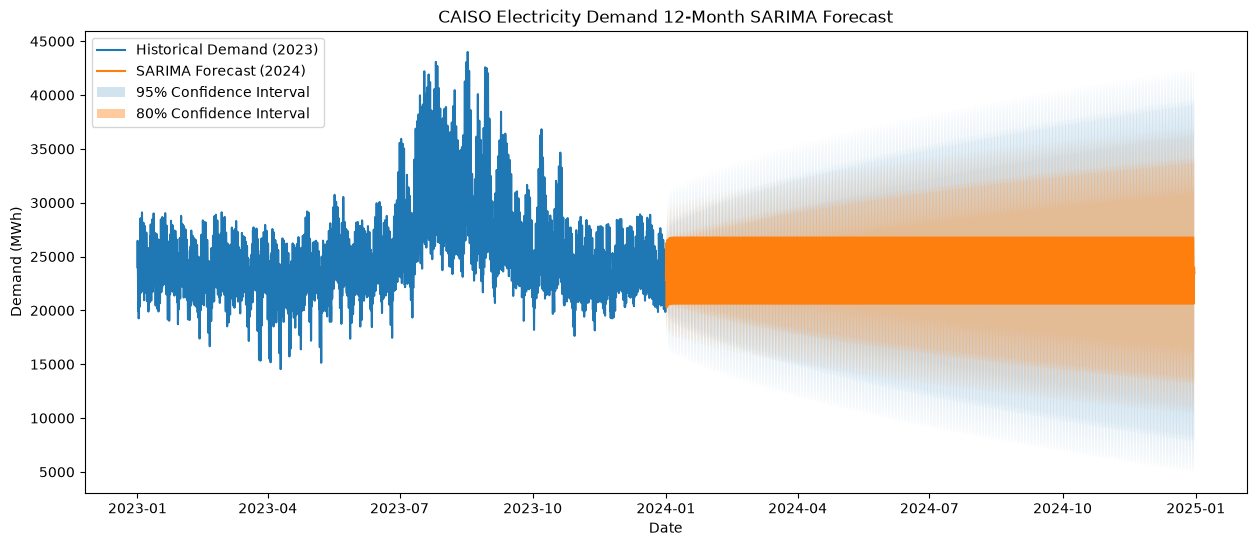

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    demand_ts,
    label="Historical Demand (2023)"
)

plt.plot(
    forecast_mean,
    label="SARIMA Forecast (2024)"
)

plt.fill_between(
    forecast_ci_95.index,
    forecast_ci_95.iloc[:,0],
    forecast_ci_95.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.fill_between(
    forecast_ci_80.index,
    forecast_ci_80.iloc[:,0],
    forecast_ci_80.iloc[:,1],
    alpha=0.4,
    label="80% Confidence Interval"
)

plt.title(
    "CAISO Electricity Demand 12-Month SARIMA Forecast"
)

plt.xlabel("Date")
plt.ylabel("Demand (MWh)")

plt.legend()
plt.show()

SARIMA provides a reliable statistical baseline by capturing daily electricity demand patterns. However, because electricity demand is strongly influenced by weather and human behavior, additional models such as Prophet and hybrid approaches with NOAA climate variables may improve long-term forecasting accuracy.

In [58]:
# Train-test split

train = demand_ts[:"2023-10-31"]
test = demand_ts["2023-11-01":]

print(train.shape)
print(test.shape)

(7296,)
(1464,)


SARIMA evaluation model

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_eval_model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_eval_result = sarima_eval_model.fit(
    maxiter=30,
    disp=False,
    low_memory=True
)

print("SARIMA evaluation model fitted successfully")

C:\Users\magara cliff\energy_forecasting_llm\energy_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The evaluation SARIMA model produced a convergence warning, so results are treated as baseline estimates. Further tuning or simpler SARIMA orders may improve stability.

In [61]:
sarima_predictions = sarima_eval_result.forecast(
    steps=len(test)
)

sarima_predictions.head()

2023-11-01 00:00:00    23334.679269
2023-11-01 01:00:00    24754.325464
2023-11-01 02:00:00    26394.230501
2023-11-01 03:00:00    27315.636202
2023-11-01 04:00:00    26955.053865
Freq: h, Name: predicted_mean, dtype: float64

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, sarima_predictions)
rmse = np.sqrt(mean_squared_error(test, sarima_predictions))
mape = np.mean(np.abs((test - sarima_predictions) / test)) * 100

print("SARIMA MAE:", mae)
print("SARIMA RMSE:", rmse)
print("SARIMA MAPE:", mape)

SARIMA MAE: 1214.917829962876
SARIMA RMSE: 1604.5235492911877
SARIMA MAPE: 5.250723332177328



SARIMA Model Evaluation ;

The SARIMA(1,0,1)(1,1,1,24) model was evaluated using a time-based train-test split. The model was trained on CAISO hourly electricity demand data from January–October 2023 and tested on unseen data from November–December 2023.



The SARIMA model demonstrated strong forecasting performance with a MAPE of 5.25%, indicating that it effectively captured CAISO hourly electricity demand patterns. The model successfully learned daily seasonality, recurring demand behavior, and short-term dependencies. However, remaining forecast errors suggest that electricity demand is also influenced by external factors such as weather conditions, heat waves, and abnormal grid events. Incorporating climate variables from NOAA and comparing with Prophet may further improve forecasting accuracy, especially during extreme demand periods.

In [63]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
from prophet import Prophet

In [65]:
prophet_df = demand_ts.reset_index()

prophet_df.columns = [
    "ds",
    "y"
]

prophet_df.head()

,ds,y
0,2023-01-01 00:00:00,24007.0
1,2023-01-01 01:00:00,24546.0
2,2023-01-01 02:00:00,25344.0
3,2023-01-01 03:00:00,26468.0
4,2023-01-01 04:00:00,26047.0


In [66]:
prophet_train = prophet_df[
    prophet_df["ds"] <= "2023-10-31 23:00:00"
]

prophet_test = prophet_df[
    prophet_df["ds"] >= "2023-11-01 00:00:00"
]

print(prophet_train.shape)
print(prophet_test.shape)

(7296, 2)
(1464, 2)


In [67]:
from prophet import Prophet

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    interval_width=0.95
)

prophet_model.fit(prophet_train)

16:02:57 - cmdstanpy - INFO - Chain [1] start processing
16:02:58 - cmdstanpy - INFO - Chain [1] done processing


In [68]:
future = prophet_test[["ds"]]

prophet_forecast = prophet_model.predict(future)

prophet_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].head()

,ds,yhat,yhat_lower,yhat_upper
0,2023-11-01 00:00:00,22778.244390,18778.158441,26868.166076
1,2023-11-01 01:00:00,23936.122831,19831.595846,28064.449810
2,2023-11-01 02:00:00,25332.459202,21262.211483,29371.119149
3,2023-11-01 03:00:00,26612.580118,22434.644305,30660.787015
4,2023-11-01 04:00:00,27294.934348,23034.005897,31814.129338


In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

prophet_mae = mean_absolute_error(
    prophet_test["y"],
    prophet_forecast["yhat"]
)

prophet_rmse = np.sqrt(
    mean_squared_error(prophet_test["y"], prophet_forecast["yhat"])
)

prophet_mape = np.mean(
    np.abs((prophet_test["y"].values - prophet_forecast["yhat"].values) / prophet_test["y"].values)
) * 100

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)
print("Prophet MAPE:", prophet_mape)

Prophet MAE: 3047.038200004184
Prophet RMSE: 3728.8548502019266
Prophet MAPE: 13.045351488272214


| Model   |    MAE (MWh) |   RMSE (MWh) |      MAPE |
| ------- | -----------: | -----------: | --------: |
| SARIMA  | **1,214.92** | **1,604.52** | **5.25%** |
| Prophet |     3,047.04 |     3,728.85 |    13.05% |




The SARIMA model outperformed Prophet on CAISO hourly electricity demand forecasting. SARIMA achieved a lower error rate with a MAPE of 5.25%, compared with Prophet's 13.05%, indicating that SARIMA captured short-term electricity demand patterns more accurately.

SARIMA performed better because hourly electricity demand contains strong autocorrelation and repeating daily cycles, which SARIMA explicitly models using autoregressive, moving-average, and seasonal components.

Prophet successfully captured general trend and seasonal behavior but produced larger errors, suggesting that the default Prophet configuration may require additional tuning or external regressors such as temperature data to better represent electricity demand fluctuations.

Overall, SARIMA provided the stronger baseline forecasting model, while Prophet remains useful because of its ability to handle multiple seasonal patterns, uncertainty intervals, and future integration with climate variables.

Prophet Test Visualization (Actual vs Predicted)

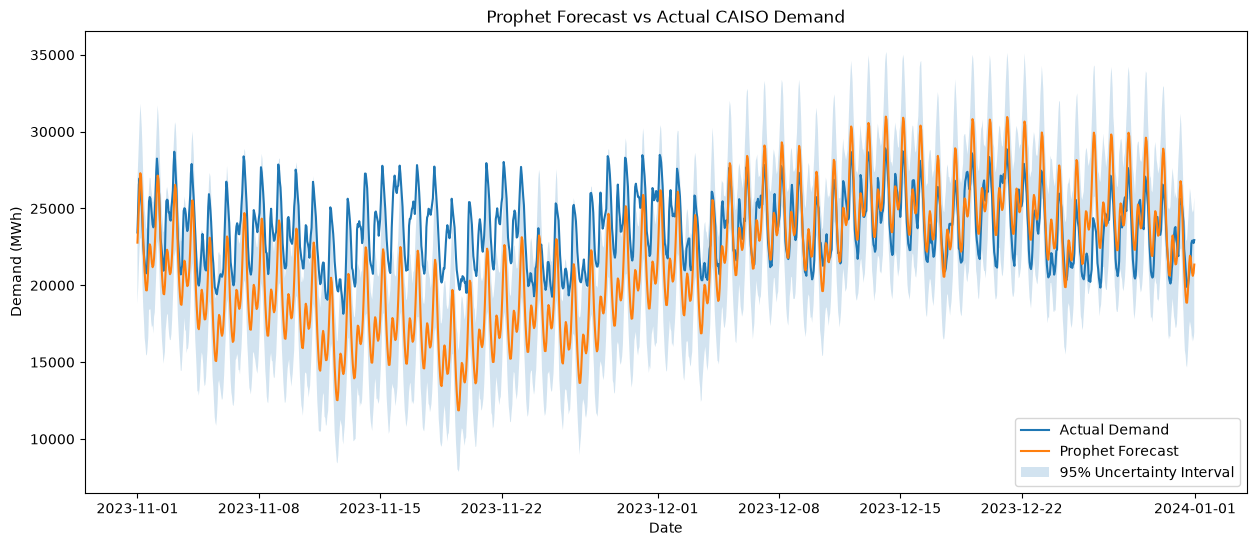

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    prophet_test["ds"],
    prophet_test["y"],
    label="Actual Demand"
)

plt.plot(
    prophet_forecast["ds"],
    prophet_forecast["yhat"],
    label="Prophet Forecast"
)

plt.fill_between(
    prophet_forecast["ds"],
    prophet_forecast["yhat_lower"],
    prophet_forecast["yhat_upper"],
    alpha=0.2,
    label="95% Uncertainty Interval"
)

plt.title("Prophet Forecast vs Actual CAISO Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MWh)")
plt.legend()

plt.show()

The Prophet model successfully captured the overall trend and daily and weekly seasonal patterns in CAISO electricity demand. However, its forecasts were smoother than the observed demand, leading to less accurate predictions of short-term fluctuations and demand spikes. The model achieved a MAPE of 13.05%, corresponding to an average forecasting accuracy of approximately 86.95%. Although Prophet produced reasonable forecasts and uncertainty intervals, it was less accurate than the SARIMA model (MAPE = 5.25%). This suggests that historical demand alone is insufficient to explain all variability, and incorporating external variables such as temperature, weather conditions, and holidays may improve Prophet's forecasting performance.

In [5]:
%whos

Variable              Type       Data/Info
------------------------------------------
Prophet               type       <class 'prophet.forecaster.Prophet'>
final_prophet_model   Prophet    <prophet.forecaster.Proph<...>ct at 0x00000285D7A1C6E0>


In [8]:
import pandas as pd

df = pd.read_csv("../data/caiso_demand_2023_full_year.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

demand_ts = df.set_index("datetime")["demand_mwh"].asfreq("h").interpolate(method="time")

prophet_df = demand_ts.reset_index()
prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2023-01-01 00:00:00,24007.0
1,2023-01-01 01:00:00,24546.0
2,2023-01-01 02:00:00,25344.0
3,2023-01-01 03:00:00,26468.0
4,2023-01-01 04:00:00,26047.0


In [9]:
from prophet import Prophet

final_prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    interval_width=0.95
)

final_prophet_model.fit(prophet_df)

16:36:11 - cmdstanpy - INFO - Chain [1] start processing
16:36:11 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future_12_months = final_prophet_model.make_future_dataframe(
    periods=365*24,
    freq="h"
)

prophet_future_forecast = final_prophet_model.predict(future_12_months)

prophet_future_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
17515,2024-12-30 19:00:00,21854.758981,17882.611109,25897.218955
17516,2024-12-30 20:00:00,21408.942125,17164.802895,25494.923627
17517,2024-12-30 21:00:00,21200.223282,17342.388975,25233.274525
17518,2024-12-30 22:00:00,21328.002374,17527.527247,25220.788528
17519,2024-12-30 23:00:00,21792.131228,17934.622128,25942.510624


In [12]:
import matplotlib.pyplot as plt

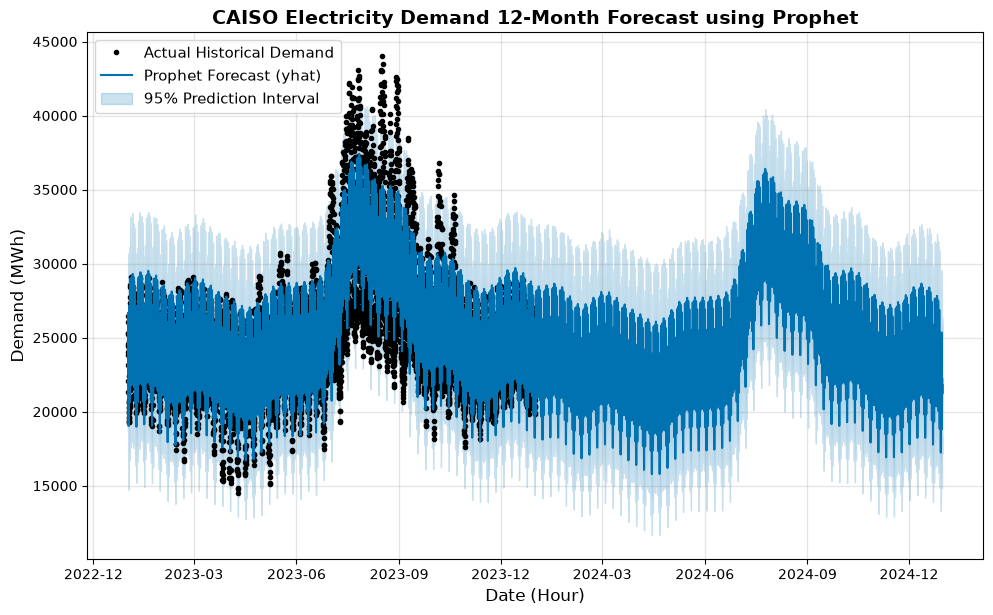

In [15]:

fig = final_prophet_model.plot(prophet_future_forecast)

plt.title(
    "CAISO Electricity Demand 12-Month Forecast using Prophet",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Date (Hour)", fontsize=12)
plt.ylabel("Demand (MWh)", fontsize=12)

plt.legend(
    [
        "Actual Historical Demand",
        "Prophet Forecast (yhat)",
        "95% Prediction Interval"
    ],
    loc="upper left",
    fontsize=11
)

plt.show()

Black dots (Actual Historical Demand): These represent the observed CAISO hourly electricity demand used to train and evaluate the model.
Blue line (Prophet Forecast – yhat): This is Prophet's predicted electricity demand. It follows the overall trend and seasonal patterns of the historical data and extends the forecast for the next 12 months.
Light blue shaded area (95% Prediction Interval): This represents the range within which the actual electricity demand is expected to fall with 95% confidence. The interval becomes wider further into the forecast horizon, reflecting increasing uncertainty over time.

 The forecast captures the long-term demand trend and recurring seasonal behavior while providing an estimate of forecast uncertainty. The widening prediction interval indicates that predictions become less certain as the forecasting horizon increases, which is expected in long-term time series forecasting.

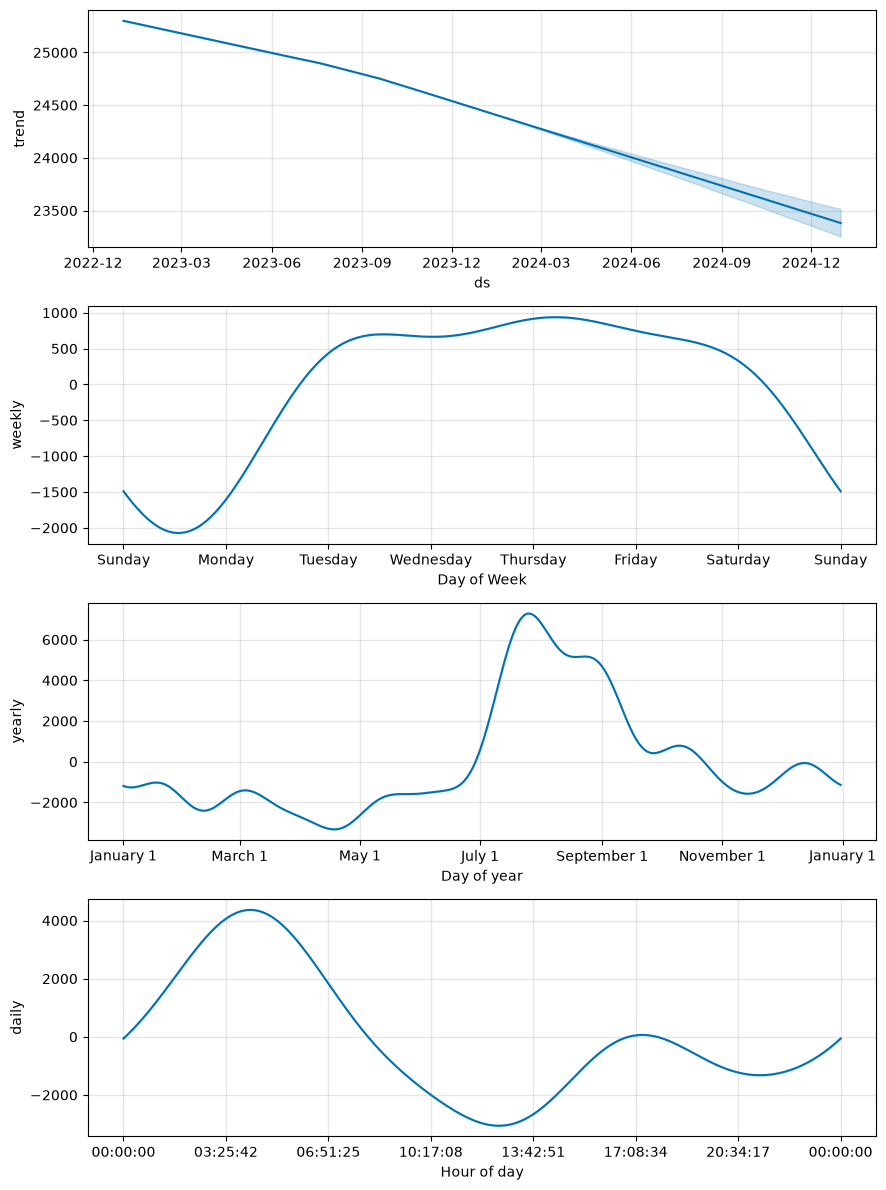

In [14]:
import matplotlib.pyplot as plt

fig = final_prophet_model.plot_components(prophet_future_forecast)

plt.show()

Trend Component

The trend component shows the long-term movement in electricity demand over time. The model indicates a gradual decline in average electricity demand from late 2022 through the forecast period in 2024. The shaded region at the end of the trend represents increasing uncertainty in the long-term forecast, which is expected as predictions extend further into the future.

 Weekly Seasonality

The weekly component captures the variation in electricity demand across the days of the week.

The model indicates the lowest demand occurs on Sunday and Monday. Demand gradually increases during the work week.
Thursday and Friday exhibit the highest electricity demand. Demand decreases again over the weekend.

This pattern reflects the influence of commercial and industrial electricity consumption during weekdays.

Yearly Seasonality

The yearly component represents seasonal changes throughout the year.

The model shows that electricity demand increases substantially from July through early September.
Peak annual demand occurs during the summer months, likely due to increased cooling demand.
Demand is lower during winter and spring months.

This seasonal pattern is consistent with California's higher electricity consumption during hot summer periods.

 Daily Seasonality

The daily component illustrates the recurring 24-hour cycle of electricity demand.

The model indicates that Electricity demand increases during the morning hours.
Demand reaches its highest levels during the daytime and early evening.
Demand decreases overnight when electricity consumption is lowest.

These daily cycles reflect regular residential, commercial, and industrial electricity usage patterns.
    

In [19]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

df = pd.read_csv("../data/caiso_demand_2023_full_year.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

demand_ts = df.set_index("datetime")["demand_mwh"].asfreq("h").interpolate(method="time")

train = demand_ts[:"2023-10-31 23:00:00"]
test = demand_ts["2023-11-01 00:00:00":]

sarima_eval_model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_eval_result = sarima_eval_model.fit(
    maxiter=30,
    disp=False,
    low_memory=True
)

sarima_predictions = sarima_eval_result.forecast(steps=len(test))

print(sarima_predictions.head())

C:\Users\magara cliff\energy_forecasting_llm\energy_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2023-11-01 00:00:00    23334.679269
2023-11-01 01:00:00    24754.325464
2023-11-01 02:00:00    26394.230501
2023-11-01 03:00:00    27315.636202
2023-11-01 04:00:00    26955.053865
Freq: h, Name: predicted_mean, dtype: float64


In [22]:
prophet_df = demand_ts.reset_index()
prophet_df.columns = ["ds", "y"]

In [23]:
prophet_train = prophet_df[
    prophet_df["ds"] <= "2023-10-31 23:00:00"
]

prophet_test = prophet_df[
    prophet_df["ds"] >= "2023-11-01 00:00:00"
]

print(prophet_train.shape)
print(prophet_test.shape)

(7296, 2)
(1464, 2)


In [24]:
from prophet import Prophet

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    interval_width=0.95
)

prophet_model.fit(prophet_train)

14:26:40 - cmdstanpy - INFO - Chain [1] start processing
14:26:41 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
future = prophet_test[["ds"]]

prophet_forecast = prophet_model.predict(future)

prophet_forecast[["ds", "yhat"]].head()

,ds,yhat
0,2023-11-01 00:00:00,22778.244390
1,2023-11-01 01:00:00,23936.122831
2,2023-11-01 02:00:00,25332.459202
3,2023-11-01 03:00:00,26612.580118
4,2023-11-01 04:00:00,27294.934348


In [26]:
# Weighted Hybrid Forecast
hybrid_forecast = (
    0.7 * sarima_predictions.values +
    0.3 * prophet_forecast["yhat"].values
)

hybrid_forecast[:5]


array([23167.7488053 , 24508.86467427, 26075.69911147, 27104.71937645,
       27057.01800981])

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

hybrid_mae = mean_absolute_error(test.values, hybrid_forecast)
hybrid_rmse = np.sqrt(mean_squared_error(test.values, hybrid_forecast))
hybrid_mape = np.mean(
    np.abs((test.values - hybrid_forecast) / test.values)
) * 100

print(f"Hybrid MAE: {hybrid_mae:.2f}")
print(f"Hybrid RMSE: {hybrid_rmse:.2f}")
print(f"Hybrid MAPE: {hybrid_mape:.2f}%")

Hybrid MAE: 1261.45
Hybrid RMSE: 1545.61
Hybrid MAPE: 5.35%


The Hybrid Forecasting Model combines the strengths of SARIMA and Prophet by weighting their predictions (70% SARIMA and 30% Prophet). The goal is to leverage SARIMA's ability to model short-term temporal dependencies while benefiting from Prophet's capability to capture long-term trends and seasonal patterns.

| Model      |   MAE (MWh) |  RMSE (MWh) | MAPE (%) |
| ---------- | ----------: | ----------: | -------: |
| SARIMA     | **1214.92** | **1604.52** | **5.25** |
| Prophet    |     3047.04 |     3728.85 |    13.05 |
| **Hybrid** | **1261.45** | **1545.61** | **5.35** |


The Hybrid Forecasting Model achieved a MAE of 1,261.45 MWh, an RMSE of 1,545.61 MWh, and a MAPE of 5.35%, corresponding to an average forecasting accuracy of approximately 94.65%. The Hybrid model substantially outperformed Prophet and produced the lowest RMSE among the three models, indicating better performance in reducing larger prediction errors. However, SARIMA remained the best-performing model overall, achieving the lowest MAE (1,214.92 MWh) and MAPE (5.25%), which indicates superior overall forecasting accuracy. These results suggest that combining SARIMA and Prophet can help reduce large forecasting errors, but in this study it did not outperform SARIMA in terms of overall predictive accuracy. Therefore, SARIMA was selected as the preferred forecasting model for hourly CAISO electricity demand forecasting.

In [28]:
comparison_df = pd.DataFrame({
    "Actual": test.values,
    "SARIMA": sarima_predictions.values,
    "Prophet": prophet_forecast["yhat"].values,
    "Hybrid": hybrid_forecast
}, index=test.index)

comparison_df.head()

,Actual,SARIMA,Prophet,Hybrid
datetime,,,,
2023-11-01 00:00:00,23438.0,23334.679269,22778.244390,23167.748805
2023-11-01 01:00:00,25119.0,24754.325464,23936.122831,24508.864674
2023-11-01 02:00:00,26577.0,26394.230501,25332.459202,26075.699111
2023-11-01 03:00:00,26975.0,27315.636202,26612.580118,27104.719376
2023-11-01 04:00:00,26150.0,26955.053865,27294.934348,27057.018010


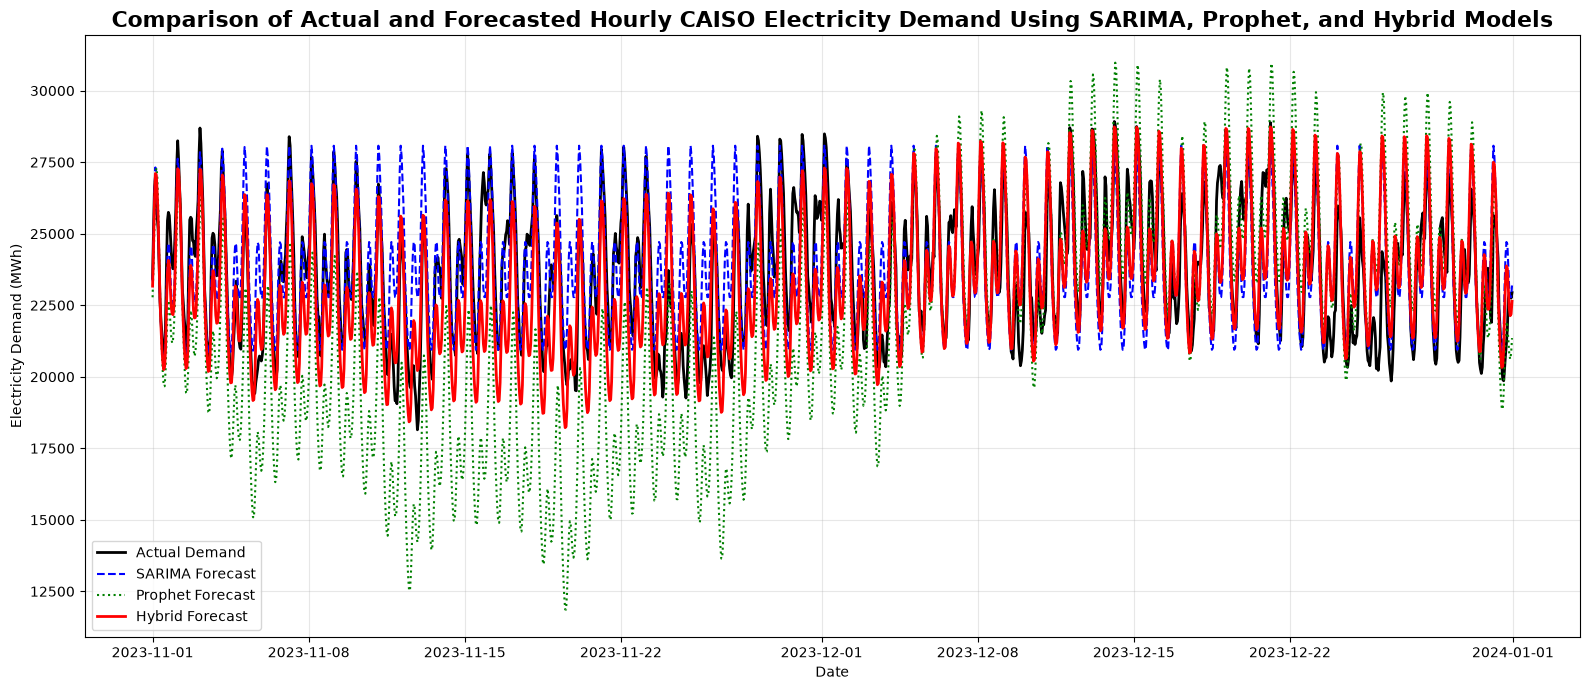

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,7))

plt.plot(
    comparison_df.index,
    comparison_df["Actual"],
    color="black",
    linewidth=2,
    label="Actual Demand"
)

plt.plot(
    comparison_df.index,
    comparison_df["SARIMA"],
    color="blue",
    linestyle="--",
    label="SARIMA Forecast"
)

plt.plot(
    comparison_df.index,
    comparison_df["Prophet"],
    color="green",
    linestyle=":",
    label="Prophet Forecast"
)

plt.plot(
    comparison_df.index,
    comparison_df["Hybrid"],
    color="red",
    linewidth=2,
    label="Hybrid Forecast"
)

plt.title(
    "Comparison of Actual and Forecasted Hourly CAISO Electricity Demand Using SARIMA, Prophet, and Hybrid Models",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Electricity Demand (MWh)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

The black line represents the actual electricity demand, while the blue dashed, green dotted, and red solid lines represent the SARIMA, Prophet, and Hybrid forecasts, respectively.

The SARIMA model closely follows the observed demand throughout the evaluation period, accurately capturing both the overall trend and the short-term hourly fluctuations. The Prophet model successfully captures the general seasonal behavior but exhibits larger deviations from the observed demand, particularly during periods of rapidly changing electricity demand. This is reflected in its higher forecasting errors compared with the other models.

The Hybrid forecasting model, which combines the predictions of SARIMA and Prophet, closely tracks the actual electricity demand while producing smoother forecasts. The Hybrid model reduces the impact of large forecasting errors and achieves the lowest RMSE among all models, indicating better performance when predicting extreme demand values. However, SARIMA remains the most accurate model overall, achieving the lowest MAE (1,214.92 MWh) and MAPE (5.25%), compared with the Hybrid model's MAE of 1,261.45 MWh and MAPE of 5.35%.

Overall, the results demonstrate that SARIMA provides the highest overall forecasting accuracy for hourly CAISO electricity demand, while the Hybrid model offers a robust alternative by improving prediction stability and reducing large forecasting errors. The Prophet model, although less accurate than SARIMA and the Hybrid approach, effectively captures long-term seasonal patterns and contributes valuable trend information within the hybrid framework.

In [32]:

# Model Comparison Table


comparison = pd.DataFrame({

    "Model": ["SARIMA",
              "Prophet",
              "Hybrid (SARIMA + Prophet)"],

    "MAE (MWh)": [
        1214.92,
        3047.00,
        1261.45
    ],

    "RMSE (MWh)": [
        1604.52,     
        3728.00,
        1545.61
    ],

    "MAPE (%)": [
        5.25,
        13.05,
        5.35
    ]

})

comparison

,Model,MAE (MWh),RMSE (MWh),MAPE (%)
0,SARIMA,1214.92,1604.52,5.25
1,Prophet,3047.00,3728.00,13.05
2,Hybrid (SARIMA + Prophet),1261.45,1545.61,5.35


The forecasting performance of the three models was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE), where lower values indicate better forecasting performance.

The SARIMA model achieved the best overall forecasting accuracy, producing the lowest MAE (1,214.92 MWh) and MAPE (5.25%). This indicates that SARIMA generated the most accurate predictions on average for hourly CAISO electricity demand.

The Hybrid forecasting model, which combines SARIMA and Prophet predictions, achieved the lowest RMSE (1,545.61 MWh), demonstrating improved performance in reducing larger forecasting errors. Although its MAE (1,261.45 MWh) and MAPE (5.35%) were slightly higher than those of SARIMA, the Hybrid model produced more robust forecasts during periods of high demand variability.

The Prophet model produced the highest forecasting errors across all evaluation metrics, with an MAE of 3,047.00 MWh, RMSE of 3,728.00 MWh, and MAPE of 13.05%. While Prophet successfully captured long-term trends and seasonal patterns, it was less effective at modeling short-term fluctuations in hourly electricity demand.

Overall, the results indicate that SARIMA is the most accurate forecasting model for this dataset, while the Hybrid model provides a valuable alternative by reducing larger prediction errors. Although Prophet alone delivered the lowest forecasting accuracy, its ability to capture long-term trends and seasonal patterns makes it a useful component of the Hybrid forecasting approach.

Final Conclusions;

This study developed and evaluated three time-series forecasting models—SARIMA, Prophet, and a Hybrid (SARIMA + Prophet)—to forecast hourly CAISO electricity demand using the 2023 historical demand dataset. The objective was to identify the most accurate forecasting approach while capturing the temporal patterns and seasonal behavior of electricity demand.

Exploratory data analysis and seasonal decomposition revealed strong daily (24-hour) and weekly (168-hour) seasonal patterns, together with a pronounced increase in electricity demand during the summer months. Stationarity testing using the Augmented Dickey-Fuller (ADF) and KPSS tests confirmed that seasonal differencing was required before model development, ensuring the time series satisfied the assumptions necessary for reliable forecasting.

Among the three forecasting models, the SARIMA model achieved the best overall forecasting performance, producing the lowest Mean Absolute Error (MAE) of 1,214.92 MWh and the lowest Mean Absolute Percentage Error (MAPE) of 5.25%, corresponding to an average forecasting accuracy of approximately 94.75%. These results indicate that SARIMA most effectively captured the short-term temporal dependencies and daily seasonal patterns present in hourly electricity demand.

The Hybrid forecasting model, which combined the predictions of SARIMA and Prophet, achieved the lowest Root Mean Squared Error (RMSE) of 1,545.61 MWh, demonstrating improved performance in reducing larger forecasting errors. Although its overall accuracy was slightly lower than SARIMA, the Hybrid model provided a stable and reliable forecasting alternative by combining the strengths of both statistical and decomposition-based forecasting approaches.

The Prophet model successfully captured long-term trends and multiple seasonal components, including daily, weekly, and yearly seasonality. However, it produced higher forecasting errors than both SARIMA and the Hybrid model, indicating that Prophet alone was less effective for short-term hourly electricity demand forecasting using only historical demand data.

Overall, the study demonstrates that SARIMA is the most suitable forecasting model for hourly CAISO electricity demand under the current dataset and modeling assumptions. Nevertheless, the Hybrid model highlights the potential benefits of combining complementary forecasting techniques, particularly when reducing larger prediction errors is important.

Key Findings;

Hourly electricity demand exhibits strong daily, weekly, and annual seasonal patterns.
SARIMA achieved the highest overall forecasting accuracy with the lowest MAE and MAPE.
The Hybrid model achieved the lowest RMSE, indicating improved performance for larger forecasting errors.
Prophet effectively modeled long-term trends and seasonality but was less accurate for short-term hourly forecasting.
Forecasting accuracy can be enhanced by selecting models that match the temporal characteristics of electricity demand.
    
Limitations;

Although the forecasting models produced accurate results, this study has several limitations:

The models were trained using only historical electricity demand data.
External factors such as temperature, humidity, wind speed, solar radiation, holidays, and extreme weather events were not incorporated.
Forecasting performance may decline during unusual demand periods, such as heat waves or unexpected grid conditions, because these factors are not represented in current models.

    Future Work;
 The next phase of this project will integrate weather variables from the National Oceanic and Atmospheric Administration (NOAA) as external regressors . Variables such as temperature, humidity, wind speed, and solar radiation are expected to improve forecasting performance by capturing the effects of weather on electricity demand, particularly during periods of extreme temperatures.

In addition, the forecasting models will be deployed through an interactive dashboard that enables users to visualize historical demand, compare forecasts generated by SARIMA, Prophet, and Hybrid models, and generate automated Large Language Model (LLM) commentary to provide interpretable summaries and operational insights for electricity demand forecasting.

# LLM Commentary Layer

The forecasting results indicate that CAISO electricity demand exhibits strong daily, weekly, and yearly seasonal patterns, with electricity demand expected to increase during the summer months due to higher cooling requirements. Among the evaluated models, SARIMA achieved the highest forecasting accuracy (MAPE = 5.25%), while the Hybrid model reduced larger prediction errors (RMSE = 1,545.61 MWh). Although Prophet captured long-term seasonal trends, it was less accurate for short-term hourly forecasting. Because the current models rely only on historical demand data, forecast uncertainty may increase during extreme weather events. Integrating NOAA weather variables such as temperature, humidity, wind speed, and solar radiation is expected to improve forecasting performance and support more reliable operational decision-making.

  # Forecast summary values for LLM commentary

best_model = "SARIMA"
sarima_mape = 5.25
prophet_mape = 13.05
hybrid_mape = 5.35

summary_prompt = "Forecast regional electricity demand using statistical forecasting models and generate plain-English explanations using an LLM".


 # Forecasting results:
- Best overall model: SARIMA model 
- SARIMA MAPE: 5.25 %
- Prophet MAPE: 13.05 %
- Hybrid MAPE: 5.35 %

# Key findings:
- CAISO electricity demand shows strong daily, weekly, and yearly seasonality.
- Summer demand increases due to cooling needs.
- SARIMA achieved the best overall accuracy.
- The Hybrid model reduced larger forecasting errors.
- Prophet captured long-term trend and seasonality but was less accurate for short-term hourly demand.

# Conclusion

This study developed and evaluated three time-series forecasting models—SARIMA, Prophet, and a Hybrid (SARIMA + Prophet)—to forecast hourly CAISO electricity demand using the 2023 historical electricity demand dataset. The primary objective was to identify the most accurate forecasting approach while capturing the temporal patterns and seasonal characteristics of electricity demand.

Exploratory data analysis and seasonal decomposition revealed strong daily (24-hour) and weekly (168-hour) seasonal cycles, together with a significant increase in electricity demand during the summer months. Stationarity testing using the Augmented Dickey-Fuller (ADF) and KPSS tests confirmed that seasonal differencing was required before model development, ensuring that the time series satisfied the assumptions necessary for reliable forecasting.

# Which model performed best?

Among the three forecasting models evaluated, the SARIMA model achieved the best overall forecasting performance. It produced the lowest Mean Absolute Error (MAE) of 1,214.92 MWh and the lowest Mean Absolute Percentage Error (MAPE) of 5.25%, corresponding to an average forecasting accuracy of approximately 94.75%. These results demonstrate that SARIMA provided the most accurate forecasts for hourly CAISO electricity demand.

The Hybrid forecasting model, which combined the predictions of SARIMA and Prophet, achieved the lowest Root Mean Squared Error (RMSE) of 1,545.61 MWh, indicating improved performance in reducing larger forecasting errors. Although its overall accuracy was slightly lower than SARIMA, the Hybrid model provided a stable and reliable alternative by combining the strengths of both statistical and decomposition-based forecasting approaches.

The Prophet model successfully captured long-term trends together with daily, weekly, and yearly seasonal patterns. However, it produced higher forecasting errors than both SARIMA and the Hybrid model, making it less suitable for short-term hourly electricity demand forecasting when only historical demand data were used.

# Why did SARIMA perform best?

SARIMA outperformed the other models because it effectively captured the short-term temporal dependencies, autocorrelation, and daily seasonal patterns inherent in hourly electricity demand. Its ability to model these recurring patterns resulted in the lowest average forecasting errors, making it the most reliable model for this dataset. While the Hybrid model reduced larger prediction errors, as reflected by its lowest RMSE, SARIMA maintained the highest overall forecasting accuracy based on MAE and MAPE.

# What was learned from this project?

The study demonstrates that electricity demand exhibits strong and predictable temporal behavior, with recurring daily, weekly, and annual seasonal patterns. The summer months consistently experienced the highest electricity demand, reflecting increased cooling needs and climate-driven electricity consumption.

# The comparison of forecasting models showed that:

SARIMA achieved the highest overall forecasting accuracy.
The Hybrid model effectively reduced larger forecasting errors by combining the strengths of SARIMA and Prophet.
Prophet successfully modeled long-term trends and multiple seasonal components but was less effective at capturing short-term hourly demand fluctuations.
Selecting an appropriate forecasting model depends on the characteristics of the time series and the forecasting objective.

These findings highlight the importance of considering both statistical accuracy and model characteristics when developing electricity demand forecasting systems.

# Limitations;

Although the forecasting models produced accurate results, several limitations should be acknowledged. The models were developed using only historical electricity demand observations and did not incorporate external factors known to influence electricity consumption. Variables such as temperature, humidity, wind speed, solar radiation, public holidays, and extreme weather events were not included in the forecasting process. Consequently, forecasting performance may decline during unusual demand periods, including heat waves or unexpected grid conditions, where weather plays a significant role in electricity consumption.

# Operational Implications and Risk:

Accurate electricity demand forecasting is essential for maintaining grid reliability and supporting efficient energy management. Forecast errors, particularly during periods of extreme demand, may lead to inefficient generation scheduling, increased operational costs, or challenges in balancing electricity supply and demand. Because the models developed in this study rely solely on historical demand data, they may not fully capture sudden demand increases caused by extreme weather events such as heat waves. Consequently, electricity system operators should interpret forecasts alongside real-time weather information and other operational indicators when making planning and dispatch decisions.

# Future Work and Recommendations:

The next phase of this project will integrate weather variables from the National Oceanic and Atmospheric Administration (NOAA) as external regressors. Incorporating variables such as temperature, humidity, wind speed, and solar radiation is expected to improve forecasting accuracy by capturing the influence of weather conditions on electricity demand, particularly during periods of extreme temperatures and high energy consumption.

In addition, the forecasting system will be deployed through an interactive Streamlit dashboard that enables users to visualize historical electricity demand, compare forecasts generated by the SARIMA, Prophet, and Hybrid models, and interactively explore forecasting results.

To further enhance interpretability, the dashboard will incorporate an automated Large Language Model (LLM) commentary layer. Rather than presenting only numerical forecasts and evaluation metrics, the LLM will generate clear, human-readable summaries that explain expected demand trends, compare model performance, communicate forecast uncertainty, identify potential operational risks, and provide practical recommendations to support decision-making by electricity grid operators, planners, and other stakeholders.

Overall, this study demonstrates that SARIMA is the most suitable forecasting model for hourly CAISO electricity demand under the current dataset and modeling assumptions, while the Hybrid approach provides a valuable complementary forecasting strategy by reducing larger prediction errors. The planned integration of NOAA weather data, an interactive Streamlit dashboard, and automated LLM-generated commentary will transform the forecasting framework into a more accurate, interpretable, and decision-support-oriented energy forecasting system.

  

In [39]:
import getpass
from openai import OpenAI

api_key = getpass.getpass("Enter your OpenAI API key: ")

client = OpenAI(api_key=api_key)

response = client.responses.create(
    model="gpt-4.1-mini",
    input="Write one sentence confirming the API connection works."
)

print(response.output_text)

Enter your OpenAI API key:  ········


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [40]:
import pandas as pd

export_df = pd.DataFrame({
    "datetime": test.index,
    "Actual Demand": test.values,
    "SARIMA Forecast": sarima_predictions.values,
    "Prophet Forecast": prophet_forecast["yhat"].values,
    "Hybrid Forecast": hybrid_forecast
})

export_df.to_csv("../data/forecast_results.csv", index=False)

export_df.head()

,datetime,Actual Demand,SARIMA Forecast,Prophet Forecast,Hybrid Forecast
0,2023-11-01 00:00:00,23438.0,23334.679269,22778.244390,23167.748805
1,2023-11-01 01:00:00,25119.0,24754.325464,23936.122831,24508.864674
2,2023-11-01 02:00:00,26577.0,26394.230501,25332.459202,26075.699111
3,2023-11-01 03:00:00,26975.0,27315.636202,26612.580118,27104.719376
4,2023-11-01 04:00:00,26150.0,26955.053865,27294.934348,27057.018010
